In [ ]:
# Introduction : A SaaS company rolled out a new collaboration feature to different user cohorts at different times. Did the feature improve retention, or were early cohorts just higher quality users? 
# I will be using Callaway & Sant'Anna estimator to find out.

In [4]:
import pandas as pd

# Import data (simulated in another file)

df = pd.read_csv(r"C:\Users\bahak\Project 3 - Staggered did\data\staggered_did_data(1).csv")

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Basic info
print(f"Shape: {df.shape}")
print(f"Head:")
print(df.head(10))

print(f"\n--- Dataset Structure ---")
print(f"Users: {df['user_id'].nunique()}")
print(f"Cohorts: {sorted(df['cohort'].unique())}")
print(f"Time period: months {df['calendar_month'].min()}–{df['calendar_month'].max()}")
print(f"Outcome (retention): {df['retention'].min():.1f}–{df['retention'].max():.1f}%")

# Treatment timing
print(f"\n--- Treatment Schedule ---")
timing = df.groupby('cohort')['treatment_month'].first()
for cohort, month in timing.items():
    print(f"Cohort {cohort}: treated month {month}")

Shape: (19200, 6)
Head:
    user_id  cohort  treatment_month  calendar_month  treated  retention
0  user_1_0       1                3               1        0  51.490142
1  user_1_0       1                3               2        0  49.585207
2  user_1_0       1                3               3        1  59.943066
3  user_1_0       1                3               4        1  62.569090
4  user_1_0       1                3               5        1  57.297540
5  user_1_0       1                3               6        1  57.297589
6  user_1_0       1                3               7        1  62.737638
7  user_1_0       1                3               8        1  60.302304
8  user_1_0       1                3               9        1  56.591577
9  user_1_0       1                3              10        1  59.627680

--- Dataset Structure ---
Users: 800
Cohorts: [1, 2, 3, 4]
Time period: months 1–24
Outcome (retention): 40.9–75.8%

--- Treatment Schedule ---
Cohort 1: treated month 3
Co

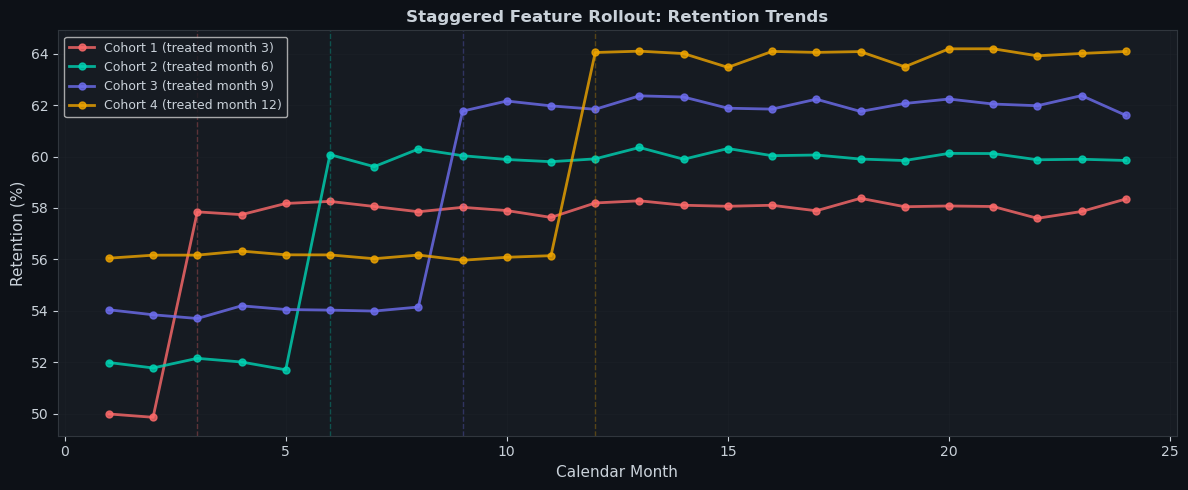

In [9]:
# Aggregate retention by cohort and month then visualising the before/after

BG = "#0d1117"
PANEL = "#161b22"
BORDER = "#30363d"
TEXT = "#c9d1d9"
TEAL = "#00d4b4"
INDIGO = "#6e6ef0"
RED = "#ff6b6b"
ORANGE = "#f0a500"

# Aggregate retention by cohort and month
cohort_monthly = df.groupby(['cohort', 'calendar_month'])['retention'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

colors = [RED, TEAL, INDIGO, ORANGE]
treatment_months = {1: 3, 2: 6, 3: 9, 4: 12}

for cohort, color in zip([1, 2, 3, 4], colors):
    cohort_data = cohort_monthly[cohort_monthly['cohort'] == cohort]
    treatment_month = treatment_months[cohort]
    
    ax.plot(cohort_data['calendar_month'], cohort_data['retention'], marker='o', label=f'Cohort {cohort} (treated month {treatment_month})',color=color, linewidth=2, markersize=5, alpha=0.8)
    ax.axvline(treatment_month, color=color, linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Calendar Month', fontsize=11, color=TEXT)
ax.set_ylabel('Retention (%)', fontsize=11, color=TEXT)
ax.set_title('Staggered Feature Rollout: Retention Trends', fontsize=12, fontweight='bold', color=TEXT)
ax.legend(fontsize=9, loc='upper left', facecolor=PANEL, labelcolor=TEXT)
ax.grid(True, alpha=0.12, color=BORDER)
ax.tick_params(colors=TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig('treatment_timeline.png', dpi=150, facecolor=BG)
plt.show()

In [ ]:
# We can notice that each cohort present a jump in retention % after the treatment (dashed line)
# Its also clear that there are flat parallel lines before treatment (did parallel trend assumption validated)
# Earlier cohorts start higher ==> creates confounding ==> biasing TFW method

In [ ]:
# Calculating ATT for each cohort independently

cohorts = sorted(df['cohort'].unique())
all_times = sorted(df['calendar_month'].unique())
treatment_month_by_cohort = df.groupby('cohort')['treatment_month'].first().to_dict()

baseline_by_cohort = {}
for cohort in cohorts:
    cohort_data = df[df['cohort'] == cohort]
    treatment_month = treatment_month_by_cohort[cohort]
    
    pre_treatment_data = cohort_data[cohort_data['calendar_month'] < treatment_month]
    baseline = pre_treatment_data['retention'].mean()
    
    baseline_by_cohort[cohort] = baseline

print("Cohort Baselines (pre-treatment average):")
for cohort in cohorts:
    print(f"  Cohort {cohort}: {baseline_by_cohort[cohort]:.2f}%")

att_results = {}
for cohort in cohorts:
    cohort_data = df[df['cohort'] == cohort]
    baseline = baseline_by_cohort[cohort]
    
    att_by_time = {}
    for t in all_times:
        outcome_at_t = cohort_data[cohort_data['calendar_month'] == t]['retention'].mean()
        att = outcome_at_t - baseline
        att_by_time[t] = att
    
    att_results[cohort] = att_by_time

print("\nATT(g,t) Cohort , Calendar Month:")
att_table = pd.DataFrame(att_results).round(2)
print(att_table)

# After treatment ATT = 8pp

Cohort Baselines (pre-treatment average):
  Cohort 1: 49.93%
  Cohort 2: 51.93%
  Cohort 3: 54.00%
  Cohort 4: 56.13%

ATT(g,t) by Cohort and Calendar Month:
       1     2     3     4
1   0.07  0.06  0.04 -0.08
2  -0.07 -0.15 -0.15  0.03
3   7.92  0.23 -0.30  0.04
4   7.81  0.08  0.20  0.19
5   8.25 -0.22  0.05  0.05
6   8.33  8.14  0.03  0.04
7   8.13  7.68 -0.01 -0.10
8   7.92  8.36  0.15  0.04
9   8.10  8.10  7.76 -0.16
10  7.97  7.95  8.16 -0.05
11  7.70  7.87  7.97  0.01
12  8.27  7.98  7.83  7.91
13  8.35  8.42  8.36  7.96
14  8.18  7.96  8.31  7.87
15  8.14  8.38  7.88  7.33
16  8.18  8.10  7.84  7.95
17  7.96  8.13  8.23  7.91
18  8.45  7.97  7.75  7.95
19  8.12  7.91  8.06  7.35
20  8.15  8.19  8.23  8.05
21  8.13  8.18  8.04  8.06
22  7.67  7.94  7.97  7.78
23  7.93  7.96  8.37  7.87
24  8.42  7.92  7.60  7.95


In [11]:
# after calculating each individual cohort treatment effect now the overall ATT :

all_post_att = []
for cohort in cohorts:
    treatment_month = treatment_month_by_cohort[cohort]
    cohort_att = att_results[cohort]
    
    for t, att_val in cohort_att.items():
        if t >= treatment_month:
            all_post_att.append(att_val)

overall_att = np.mean(all_post_att)
overall_se = np.std(all_post_att) / np.sqrt(len(all_post_att))

print(f"Callaway & Sant'Anna Estimate:")
print(f"Overall ATT:    {overall_att:.3f}pp")
print(f"Std. Error:     {overall_se:.3f}")
print(f"95% CI:         [{overall_att - 1.96*overall_se:.3f}, {overall_att + 1.96*overall_se:.3f}]")
print(f"\nTrue Effect:    8.000pp")
print(f"Estimated:      {overall_att:.3f}pp")
print(f"Error:          {abs(8.0 - overall_att):.3f}pp")

Callaway & Sant'Anna Estimate:
Overall ATT:    8.022pp
Std. Error:     0.027
95% CI:         [7.968, 8.075]

True Effect:    8.000pp
Estimated:      8.022pp
Error:          0.022pp


In [12]:

# Calculating relative time for each cohort time observation to showcase the dynamic effect of treatment
relative_att = {}

for cohort in cohorts:
    treatment_month = treatment_month_by_cohort[cohort]
    cohort_att = att_results[cohort]
    
    relative_att[cohort] = {}
    for calendar_t, att_value in cohort_att.items():
        relative_t = calendar_t - treatment_month
        relative_att[cohort][relative_t] = att_value

event_study = {}
for rel_t in range(-12, 13):  
    att_at_rel_t = []
    for cohort in cohorts:
        if rel_t in relative_att[cohort]:
            att_at_rel_t.append(relative_att[cohort][rel_t])
    
    if att_at_rel_t:
        event_study[rel_t] = np.mean(att_at_rel_t)

event_study_sorted = {k: v for k, v in sorted(event_study.items())}

print("Event Study: ATT by Relative Time")
print("(Relative month = calendar month - treatment month)")
print()
for rel_t, att_val in event_study_sorted.items():
    marker = "[PRE]" if rel_t < 0 else "[POST]"
    print(f"  Relative month {rel_t:3d}: ATT = {att_val:7.3f}pp {marker}")

Event Study: ATT by Relative Time
(Relative month = calendar month - treatment month)

  Relative month -11: ATT =  -0.084pp [PRE]
  Relative month -10: ATT =   0.033pp [PRE]
  Relative month  -9: ATT =   0.035pp [PRE]
  Relative month  -8: ATT =   0.117pp [PRE]
  Relative month  -7: ATT =  -0.053pp [PRE]
  Relative month  -6: ATT =  -0.127pp [PRE]
  Relative month  -5: ATT =   0.051pp [PRE]
  Relative month  -4: ATT =  -0.020pp [PRE]
  Relative month  -3: ATT =   0.029pp [PRE]
  Relative month  -2: ATT =   0.022pp [PRE]
  Relative month  -1: ATT =  -0.031pp [PRE]
  Relative month   0: ATT =   7.934pp [POST]
  Relative month   1: ATT =   7.901pp [POST]
  Relative month   2: ATT =   8.111pp [POST]
  Relative month   3: ATT =   7.899pp [POST]
  Relative month   4: ATT =   8.098pp [POST]
  Relative month   5: ATT =   8.005pp [POST]
  Relative month   6: ATT =   7.974pp [POST]
  Relative month   7: ATT =   7.897pp [POST]
  Relative month   8: ATT =   7.987pp [POST]
  Relative month   9: AT

In [ ]:
# Pre treatment (months -11 to -1) ATT lives around 0 ==> Parallel trends confirmed
# At treatment (month 0): Sharp jump to 7.93pp ==> Treatment started
# Post treatment (months 1-12): stable = 8pp ==> Persistent effect with no no decay

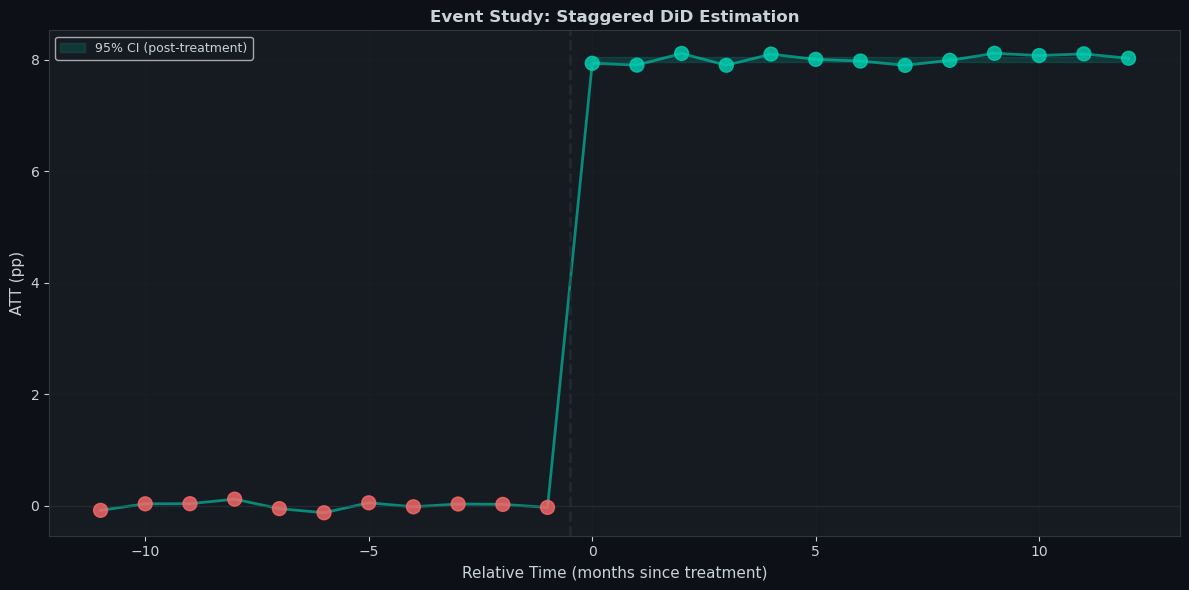

Pre-treatment mean:  -0.003pp
Post-treatment mean: 8.009pp


In [13]:
# Calculating pre and post ATT means + std for confidence intervalls for visualisation

pre_att = [v for k, v in event_study_sorted.items() if k < 0]
post_att = [v for k, v in event_study_sorted.items() if k >= 0]

pre_mean = np.mean(pre_att)
pre_std = np.std(pre_att)
post_mean = np.mean(post_att)
post_std = np.std(post_att)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

rel_times = sorted(event_study_sorted.keys())
att_values = [event_study_sorted[t] for t in rel_times]

colors_line = [RED if t < 0 else TEAL for t in rel_times]

ax.scatter(rel_times, att_values, color=colors_line, s=100, zorder=3, alpha=0.8)
ax.plot(rel_times, att_values, color=TEAL, linewidth=2, alpha=0.6, zorder=2)

ax.axhline(0, color=BORDER, linestyle='-', linewidth=1, alpha=0.5)
ax.axvline(-0.5, color=BORDER, linestyle='--', linewidth=2, alpha=0.5)  # Treatment boundary

ax.fill_between(rel_times, post_mean - 1.96*post_std/np.sqrt(len(post_att)), post_mean + 1.96*post_std/np.sqrt(len(post_att)), where=[t >= 0 for t in rel_times], color=TEAL, alpha=0.15, label='95% CI (post-treatment)')

ax.set_xlabel('Relative Time (months since treatment)', fontsize=11, color=TEXT)
ax.set_ylabel('ATT (pp)', fontsize=11, color=TEXT)
ax.set_title('Event Study: Staggered DiD Estimation', fontsize=12, fontweight='bold', color=TEXT)
ax.legend(fontsize=9, loc='upper left', facecolor=PANEL, labelcolor=TEXT)
ax.grid(True, alpha=0.12, color=BORDER)
ax.tick_params(colors=TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig('event_study.png', dpi=150, facecolor=BG)
plt.show()

print(f"Pre-treatment mean:  {pre_mean:.3f}pp")
print(f"Post-treatment mean: {post_mean:.3f}pp")

In [16]:
# Now we run DiD assumptions tests to make sure results are valid
from scipy.stats import t
# TEST 1: Pre-trend test (are pre-treatment ATTs significantly different from 0?)
pre_att_values = [v for k, v in event_study_sorted.items() if k < 0]
pre_att_mean = np.mean(pre_att_values)
pre_att_se = np.std(pre_att_values) / np.sqrt(len(pre_att_values))
pre_t_stat = pre_att_mean / pre_att_se
pre_p_value = 2 * (1 -  t.cdf(abs(pre_t_stat), len(pre_att_values) - 1))

print("TEST 1: Pre-Trend Test (Parallel Trends)")
print(f"H0: Pre-treatment ATT = 0")
print(f"Pre-treatment mean: {pre_att_mean:.4f}pp")
print(f"Std. Error:        {pre_att_se:.4f}")
print(f"t-statistic:       {pre_t_stat:.3f}")
print(f"Fail to reject H0? YES " if abs(pre_t_stat) < 1.96 else f"  Reject H0? YES ")
print()

# TEST 2: Placebo test (assign fake treatment to pre-period, should find no effect)
fake_post_att = [v for k, v in event_study_sorted.items() if -6 <= k < 0]
fake_att_mean = np.mean(fake_post_att)

print("TEST 2: Placebo Test (Fake Treatment in Pre-Period)")
print(f"Fake treatment window: months -6 to -1")
print(f"Placebo ATT mean:      {fake_att_mean:.3f}pp")
print(f"Should be ~0?          YES " if abs(fake_att_mean) < 0.2 else f"  Should be ~0?          NO ")
print()

# TEST 3: Cohort-level heterogeneity (do all cohorts have similar effects?)
print("TEST 3: Cohort-Specific Effects (Homogeneity Check)")
cohort_effects = {}
for cohort in cohorts:
    treatment_month = treatment_month_by_cohort[cohort]
    cohort_att = att_results[cohort]
    
    post_att = [v for t, v in cohort_att.items() if t >= treatment_month]
    cohort_effects[cohort] = np.mean(post_att)
    print(f"  Cohort {cohort}: {cohort_effects[cohort]:.3f}pp")

effect_range = max(cohort_effects.values()) - min(cohort_effects.values())
print(f"Range:         {effect_range:.3f}pp (should be small)")
print(f"Homogeneous?   YES " if effect_range < 0.5 else f"  Homogeneous?   NO ")

TEST 1: Pre-Trend Test (Parallel Trends)
H0: Pre-treatment ATT = 0
Pre-treatment mean: -0.0026pp
Std. Error:        0.0198
t-statistic:       -0.132
Fail to reject H0? YES 

TEST 2: Placebo Test (Fake Treatment in Pre-Period)
Fake treatment window: months -6 to -1
Placebo ATT mean:      -0.013pp
Should be ~0?          YES 

TEST 3: Cohort-Specific Effects (Homogeneity Check)
  Cohort 1: 8.094pp
  Cohort 2: 8.061pp
  Cohort 3: 8.022pp
  Cohort 4: 7.843pp
Range:         0.251pp (should be small)
Homogeneous?   YES 


In [ ]:
# TWFE Estimation to compare it to CS

df_twfe = df.copy()
df_twfe['retention_demeaned'] = df_twfe['retention'].astype(float)
df_twfe['treated_demeaned'] = df_twfe['treated'].astype(float)

for cohort in cohorts:
    mask = df_twfe['cohort'] == cohort
    df_twfe.loc[mask, 'retention_demeaned'] -= df_twfe[mask]['retention'].mean()
    df_twfe.loc[mask, 'treated_demeaned'] -= df_twfe[mask]['treated'].mean()

for t in df_twfe['calendar_month'].unique():
    mask = df_twfe['calendar_month'] == t
    df_twfe.loc[mask, 'retention_demeaned'] -= df_twfe[mask]['retention'].mean()
    df_twfe.loc[mask, 'treated_demeaned'] -= df_twfe[mask]['treated'].mean()

X = df_twfe['treated_demeaned'].values.reshape(-1, 1)
y = df_twfe['retention_demeaned'].values
X_const = np.column_stack([np.ones(len(X)), X])

coef = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ y
beta_twfe = coef[1]
residuals = y - X_const @ coef
se_twfe = np.sqrt(np.var(residuals) * np.linalg.inv(X_const.T @ X_const)[1, 1])

print("TWFE Estimate:")
print(f"β (Treatment effect): {beta_twfe:.3f}pp")
print(f"Std. Error:           {se_twfe:.3f}")
print(f"95% CI:               [{beta_twfe - 1.96*se_twfe:.3f}, {beta_twfe + 1.96*se_twfe:.3f}]")

TWFE Estimate:
  β (Treatment effect): 7.883pp
  Std. Error:           0.090
  95% CI:               [7.707, 8.058]


In [19]:
# Comparing CS vs TWFE (which should be biased in this case)
cs_estimate = 8.022
twfe_estimate = 7.883  # From earlier
true_effect = 8.0

print("COMPARISON: Callaway & Sant'Anna vs Biased TWFE")
print("="*50)
print(f"True effect (simulated):  {true_effect:.3f}pp")
print(f"CS estimate:              {cs_estimate:.3f}pp (error: {abs(cs_estimate - true_effect):.3f}pp)")
print(f"TWFE estimate:            {twfe_estimate:.3f}pp (error: {abs(twfe_estimate - true_effect):.3f}pp)")
print()
print(f"TWFE Bias: {true_effect - twfe_estimate:.3f}pp ({(true_effect - twfe_estimate)/true_effect*100:.1f}%)")
print(f"CS Bias:   {true_effect - cs_estimate:.3f}pp ({(true_effect - cs_estimate)/true_effect*100:.1f}%)")

COMPARISON: Callaway & Sant'Anna vs Biased TWFE
True effect (simulated):  8.000pp
CS estimate:              8.022pp (error: 0.022pp)
TWFE estimate:            7.883pp (error: 0.117pp)

TWFE Bias: 0.117pp (1.5%)
CS Bias:   -0.022pp (-0.3%)
